In [1]:
import numpy
import cProfile, pstats
from mandelbrotFunc import compute_mandelbrot_naive, compute_mandelbrot_numpy, compute_mandelbrot_naive_numba, compute_mandelbrot_hybrid, compute_mandelbrot_numba_typed, compute_mandelbrot_numba_parallel, compute_mandelbrot_numba_typed_jit
from mandelbrotBenchmark import benchmark, bench
import time
import matplotlib.pyplot as plt

In [2]:
# MILESTONE 1

cProfile.run('compute_mandelbrot_naive(-2, 1, -1.5, 1.5, 1024, 1024, 100, display=False)', 'naive_profile.prof')
cProfile.run('compute_mandelbrot_numpy(-2, 1, -1.5, 1.5, 1024, 1024, 100, display=False)', 'numpy_profile.prof')

for name in ('naive_profile.prof', 'numpy_profile.prof'):
    stats = pstats.Stats(name)
    stats.sort_stats('cumulative')
    stats.print_stats(10)

Tue Mar  3 16:20:59 2026    naive_profile.prof

         23022663 function calls in 7.363 seconds

   Ordered by: cumulative time
   List reduced from 19 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    7.363    7.363 {built-in method builtins.exec}
        1    0.002    0.002    7.362    7.362 <string>:1(<module>)
        1    5.652    5.652    7.360    7.360 c:\Users\danie\NSC-Mandelbrot\mandelbrotFunc.py:5(compute_mandelbrot_naive)
 21959734    1.608    0.000    1.608    0.000 {built-in method builtins.abs}
  1049600    0.077    0.000    0.077    0.000 {method 'append' of 'list' objects}
     1025    0.016    0.000    0.023    0.000 c:\Users\danie\NSC-Mandelbrot\.venv\lib\site-packages\numpy\_core\function_base.py:25(linspace)
     1025    0.003    0.000    0.003    0.000 {built-in method numpy.arange}
     1025    0.001    0.000    0.001    0.000 {method 'reshape' of 'numpy.ndarray' objects}
     1

MILESTONE 1

Q: Which function takes most total time?
A: Naive takes the most time to run

Q: Are there functions called surprisingly many times?
A: Some are called more than 20 million times

Q: How does the NumPy profile compare to naive?
A: Still faster, fewer calls, has more functions than Naive

MILESTONE 1

Q: Which function takes most total time?
A: compute_mandelbrot_naive, is the function that takes the longest

Q: Are there functions called surprisingly many times?
A: yeah, some are still called more than 20 million times

Q: How does NumPy profile compare to naive?
A: still faster, fewer calls, has more functions than Naive

Q: Where does NumPy spend its time?
A: it spends 1.158 seconds on the compute_mandelbrot_numpy function, and next most on {built-in method numpy.core._multiarray_umath.implement_array_function} with 0.004 seconds

MILESTONE 2

Q: cProfile on naive vs NumPy: How many functions appear in each profile?
A: Naive has 35 functions, and Numpy has 66 functions
Q: What does this difference tell you about where the work actually happens?
A: Naive spends its time in the interpreter, where Numpy spends its time preparing the data, so the heavy lifting can be done by pre-compiled C code

Q: Line profiler on naive: Which lines dominate runtime?
A: The lines in the innermost loop, where we calculate z with 36.7s, and check if abs(z) is greater than 2 with 38.3s
Q: What fraction of total time is spent in the inner loop?
A: The fraction is 925/1000

Q: Based on your profiling results: why is NumPy faster than naive Python?
A: Because Numpy doesn't have multiple nested loops.

Q: What would you need to change to make the naive version faster?
A: Avoid using abs(), and pre-allocate the list instead of using append, because it can make python re-allocate memory for the entire list

In [3]:
# MILESTONE 3
_ = compute_mandelbrot_naive( -2 , 1, -1.5 , 1.5 , 1024 , 1024, 100, False)
_ = compute_mandelbrot_numpy( -2 , 1, -1.5 , 1.5 , 1024 , 1024, 100, False)
_ = compute_mandelbrot_naive_numba( -2 , 1, -1.5 , 1.5 , 1024 , 1024, 100, False)

args = ( -2 , 1, -1.5 , 1.5 , 1024 , 1024, 100, False)
t_naive = bench(compute_mandelbrot_naive, *args)
t_numpy = bench(compute_mandelbrot_numpy, *args)
t_numba = bench(compute_mandelbrot_naive_numba, *args)
print (f" Naive : { t_naive:.3f}s")
print (f" NumPy : { t_numpy:.3f}s ({ t_naive / t_numpy:.1f}x)")
print (f" Numba : { t_numba:.3f}s ({ t_naive / t_numba:.1f}x)")

 Naive : 3.871s
 NumPy : 0.772s (5.0x)
 Numba : 0.053s (73.3x)


float16: 0.211s
float32: 0.252s
float64: 0.302s
Max diff float32 vs float64: 0
Max diff float16 vs float64: 0


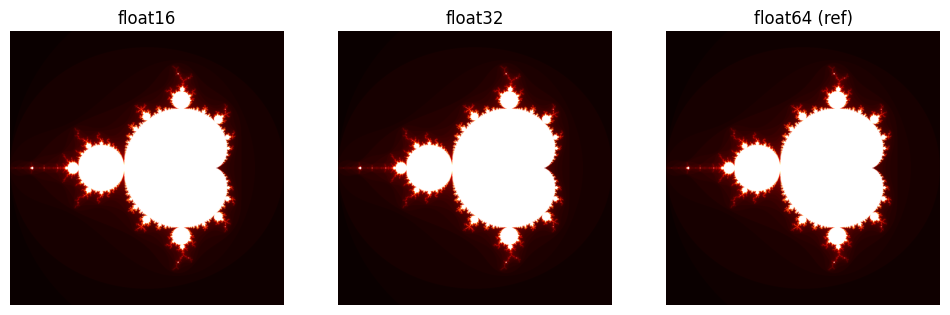

In [4]:
# MILESTONE 4
_ = compute_mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 1024, 1024, 100)

for dtype in [numpy.float16, numpy.float32, numpy.float64]:
    t0 = time.perf_counter()
    compute_mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 1024, 1024, 100, dtype=dtype)
    print(f"{dtype.__name__}: {time.perf_counter()-t0:.3f}s")

r16 = compute_mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 1024, 1024, 100, dtype=numpy.float16)
r32 = compute_mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 1024, 1024, 100, dtype=numpy.float32)
r64 = compute_mandelbrot_numba_typed(-2 ,1 ,-1.5 ,1.5, 1024, 1024, 100, dtype=numpy.float64)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, result, title in zip(axes, [r16, r32, r64], ['float16', 'float32', 'float64 (ref)']):
    ax.imshow(result, cmap='hot')
    ax.set_title(title); ax.axis('off')
plt.savefig('precision_comparison.png', dpi=150)
print(f"Max diff float32 vs float64: {numpy.abs(r32 - r64).max()}")
print(f"Max diff float16 vs float64: {numpy.abs(r16 - r64).max()}")

MILESTONE 4

Q: Speed: Does float32 actually run faster than float64 on your hardware?
A: somes times float32 takes between 0.002-0.023 seconds less than float64, but apart from that, no
Q: By how much?
A: 0.002-0.023 seconds

Q: float16: Try it with NumPy — is it faster than float32?
A: Yes it's faster by 0.011 seconds. float16 = 1.138, float32 = 1.149

Q: Visual quality: Zoom in on a detailed region of the Mandelbrot set. Can you see artefacts with float16?
A: Yes, I can see artifacts
Q: What about float32?
A: Yes, I can also see artifacts using float32

Q: Recommendation: Based on what you observe, which precision would you choose for production use, and why?
A: I would use float32 because its more than 4 times faster than float16 and is around the same speed as float64, and the accuracy is the same across float16, float32 and float64

MILESTONE 4
Data Type Section

Measured runtimes:
float16: 1.166s
float32: 0.240s
float64: 0.240s

Side-by-Side images:
Look above for image

Recommendation:
I would use float32 because its more than 4 times faster than float16 and is around the same speed as float64, and the accuracy is the same across float16, float32 and float64

MILESTONE 5

Experiment 1

In [5]:
# njit
_ = compute_mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 1024, 1024, 100)

for dtype in [numpy.float16, numpy.float32, numpy.float64]:
    t0 = time.perf_counter()
    compute_mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 1024, 1024, 100, dtype=dtype)
    print(f"{dtype.__name__}: {time.perf_counter()-t0:.3f}s")

float16: 0.052s
float32: 0.052s
float64: 0.052s


In [6]:
# jit
_ = compute_mandelbrot_numba_typed_jit(-2, 1, -1.5, 1.5, 1024, 1024, 100)

for dtype in [numpy.float16, numpy.float32, numpy.float64]:
    t0 = time.perf_counter()
    compute_mandelbrot_numba_typed_jit(-2, 1, -1.5, 1.5, 1024, 1024, 100, dtype=dtype)
    print(f"{dtype.__name__}: {time.perf_counter()-t0:.3f}s")

float16: 0.251s
float32: 0.218s
float64: 0.215s


njit is clearly faster across all floats

Experiment 2

In [7]:
_ = compute_mandelbrot_numba_parallel(-2, 1, -1.5, 1.5, 1024, 1024, 100)

for dtype in [numpy.float16, numpy.float32, numpy.float64]:
    t0 = time.perf_counter()
    compute_mandelbrot_numba_parallel(-2, 1, -1.5, 1.5, 1024, 1024, 100, dtype=dtype)
    print(f"{dtype.__name__}: {time.perf_counter()-t0:.3f}s")

float16: 1.166s
float32: 1.091s
float64: 1.173s


Using parallel and prange, decreased the speed by around 23x

Experiment 3

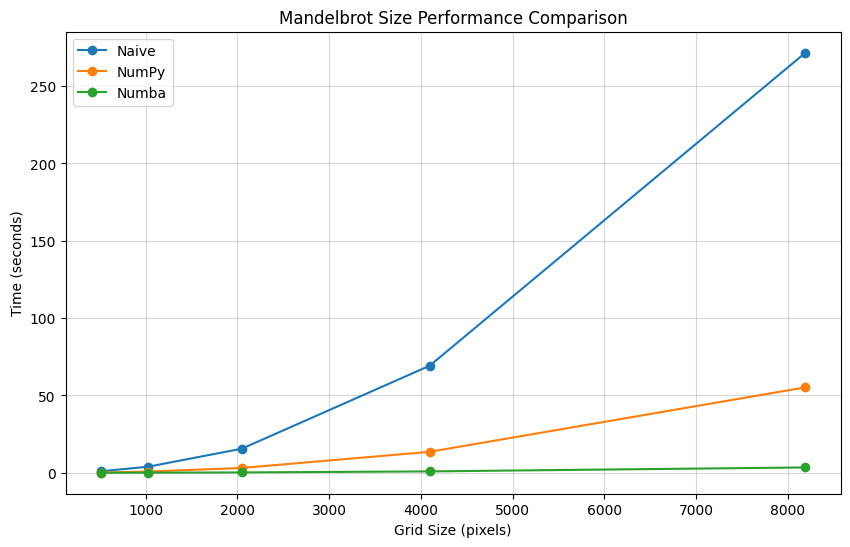

In [8]:
sizes = [512, 1024, 2048, 4096, 4096*2]
results = {"Naive": [], "NumPy": [], "Numba": []}

_ = compute_mandelbrot_naive_numba(-2, 1, -1.5, 1.5, 128, 128, 100)

for size in sizes:
    for name, func in [("Naive", compute_mandelbrot_naive), ("NumPy", compute_mandelbrot_numpy), ("Numba", compute_mandelbrot_naive_numba)]:
        t0 = time.perf_counter()
        func(-2, 1, -1.5, 1.5, size, size, 100)
        results[name].append(time.perf_counter() - t0)

plt.figure(figsize=(10, 6))
for name, times in results.items():
    plt.plot(sizes, times, marker='o', label=name)

plt.xlabel('Grid Size (pixels)')
plt.ylabel('Time (seconds)')
plt.title('Mandelbrot Size Performance Comparison')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

Q: Does speedup scale with problem size?
A: Yes, speedup scales with problem size. The larger the grid, the greater the benefit of optimized implementations